# Import library and data to pre processing

In [351]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import seaborn as sns
import seaborn as sn

In [352]:
# import files
dataset = pd.read_csv('FlightDelays_midterm.csv')
dataset.sample
dataset.head(5)

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,01/01/2004,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,01/01/2004,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,01/01/2004,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,01/01/2004,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,01/01/2004,7792,IAD,0,4,1,N698BR,ontime


<Axes: >

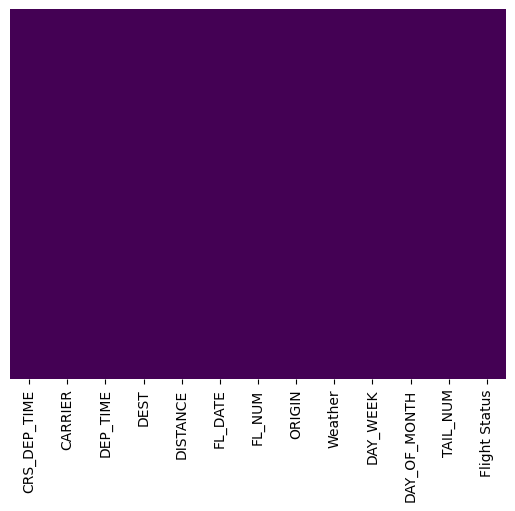

In [353]:
# look for missing data first
sns.heatmap(dataset.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [354]:
## List all categorical features which are missing
categorical_columns = dataset.select_dtypes(include=['object']).columns
print(categorical_columns)

for i in categorical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['CARRIER', 'DEST', 'FL_DATE', 'ORIGIN', 'TAIL_NUM', 'Flight Status'], dtype='object')


In [355]:
## List all numerical features which are missing
numerical_columns = dataset.select_dtypes(exclude=['object']).columns
print(numerical_columns)

for i in numerical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['CRS_DEP_TIME', 'DEP_TIME', 'DISTANCE', 'FL_NUM', 'Weather', 'DAY_WEEK',
       'DAY_OF_MONTH'],
      dtype='object')


In [356]:
dataset.dtypes

CRS_DEP_TIME      int64
CARRIER          object
DEP_TIME          int64
DEST             object
DISTANCE          int64
FL_DATE          object
FL_NUM            int64
ORIGIN           object
Weather           int64
DAY_WEEK          int64
DAY_OF_MONTH      int64
TAIL_NUM         object
Flight Status    object
dtype: object

In [357]:
# Covert from here
from sklearn.preprocessing import LabelEncoder
flight_status_mapping = {'delayed': 0, 'ontime': 1}



dataset['FT-ONTIME'] = dataset['Flight Status'].map(flight_status_mapping)
dataset['MIN_MAX_CRS_DEP_TIME'] = dataset['CRS_DEP_TIME']
dataset['MIN_MAX_DEP_TIME'] = dataset['DEP_TIME']
dataset['MIN_MAX_DISTANCE'] = dataset['DISTANCE']
dataset['MIN_MAX_DAY'] = dataset['DAY_WEEK']

In [358]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Assuming dataset_model is your DataFrame
scaler = MinMaxScaler()

# Scale the 'Age' and 'Fare' columns to the range [0, 1]
dataset[['DISTANCE', 'FT-ONTIME' , 'MIN_MAX_DEP_TIME','MIN_MAX_DISTANCE', 'MIN_MAX_DAY']] = scaler.fit_transform(dataset[['DISTANCE', 'FT-ONTIME' , 'MIN_MAX_DEP_TIME','MIN_MAX_DISTANCE', 'MIN_MAX_DAY']])

In [359]:
dataset.head(1)

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status,FT-ONTIME,MIN_MAX_CRS_DEP_TIME,MIN_MAX_DEP_TIME,MIN_MAX_DISTANCE,MIN_MAX_DAY
0,1455,OH,1455,JFK,0.25,01/01/2004,5935,BWI,0,4,1,N940CA,ontime,1.0,1455,0.622845,0.25,0.5


# Feature Selection Step

                      CRS_DEP_TIME  DEP_TIME  DISTANCE    FL_NUM   Weather  \
CRS_DEP_TIME              1.000000  0.983523  0.062368  0.086920 -0.008266   
DEP_TIME                  0.983523  1.000000  0.057680  0.105660  0.019001   
DISTANCE                  0.062368  0.057680  1.000000  0.421937  0.033104   
FL_NUM                    0.086920  0.105660  0.421937  1.000000  0.042076   
Weather                  -0.008266  0.019001  0.033104  0.042076  1.000000   
DAY_WEEK                  0.051766  0.051868 -0.020926  0.018604 -0.123636   
DAY_OF_MONTH              0.002324  0.000132  0.010121 -0.009268  0.144034   
FT-ONTIME                -0.112474 -0.170116  0.018794 -0.100394 -0.247217   
MIN_MAX_CRS_DEP_TIME      1.000000  0.983523  0.062368  0.086920 -0.008266   
MIN_MAX_DEP_TIME          0.983523  1.000000  0.057680  0.105660  0.019001   
MIN_MAX_DISTANCE          0.062368  0.057680  1.000000  0.421937  0.033104   
MIN_MAX_DAY               0.051766  0.051868 -0.020926  0.018604

<ipython-input-360-3ca4ab607a42>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = dataset.corr()


<Axes: >

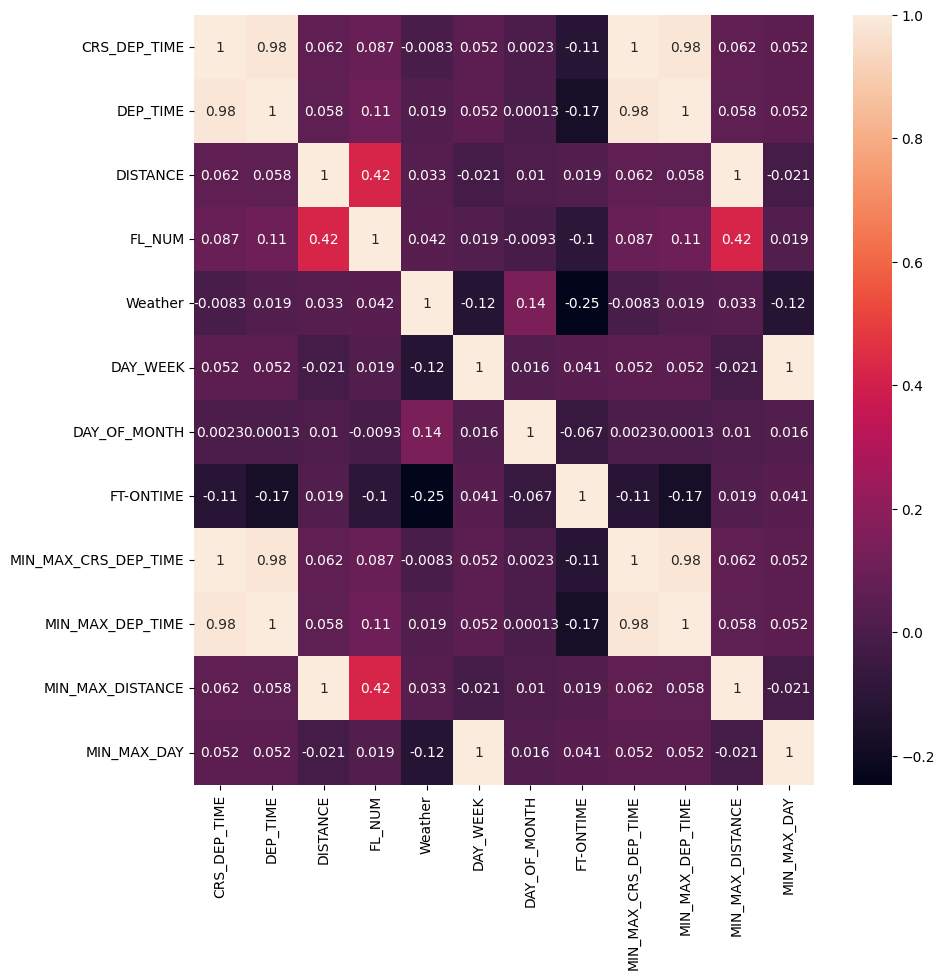

In [360]:
corr_matrix = dataset.corr()
print(corr_matrix)
fig, ax = plt.subplots(figsize=(10,10))
sn.heatmap(corr_matrix, annot=True)

In [361]:
# Training Set
x = dataset[['MIN_MAX_CRS_DEP_TIME'	,'MIN_MAX_DEP_TIME'	,'MIN_MAX_DISTANCE'	,'MIN_MAX_DAY' , 'Weather']]
# x1 = dataset['lstat']
# x2 = dataset['rm']
y = dataset['FT-ONTIME']
x.head

<bound method NDFrame.head of       MIN_MAX_CRS_DEP_TIME  MIN_MAX_DEP_TIME  MIN_MAX_DISTANCE  MIN_MAX_DAY  \
0                     1455          0.622845          0.250000     0.500000   
1                     1640          0.702586          0.733333     0.500000   
2                     1245          0.532328          1.000000     0.500000   
3                     1715          0.732328          1.000000     0.500000   
4                     1039          0.441810          1.000000     0.500000   
...                    ...               ...               ...          ...   
2196                   645          0.273276          0.500000     0.833333   
2197                  1700          0.708190          0.733333     0.833333   
2198                  1600          0.667241          0.500000     0.833333   
2199                  1359          0.600431          0.500000     0.833333   
2200                  1730          0.743966          0.500000     0.833333   

      Weather  
0           0  
1           0  
2           0  
3           0  
4           0  
...       ...  
2196        0  
2197        0  
2198        0  
2199        0  
2200        0  

[2201 rows x 5 columns]>

In [362]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

print(x_train)

      MIN_MAX_CRS_DEP_TIME  MIN_MAX_DEP_TIME  MIN_MAX_DISTANCE  MIN_MAX_DAY  \
987                    700          0.278017          0.000000     0.333333   
375                   2120          0.908621          0.733333     0.166667   
1071                   645          0.272845          0.500000     0.500000   
37                    1730          0.739655          0.500000     0.500000   
282                    700          0.316379          0.000000     0.000000   
...                    ...               ...               ...          ...   
960                   1830          0.782328          0.733333     0.333333   
905                    700          0.277155          0.000000     0.166667   
1096                   730          0.314224          0.750000     0.666667   
235                   1645          0.728448          0.983333     0.000000   
1061                  1455          0.620690          0.000000     0.500000   

      Weather  
987         0  
375         0  
107

In [363]:
print(x_test)

      MIN_MAX_CRS_DEP_TIME  MIN_MAX_DEP_TIME  MIN_MAX_DISTANCE  MIN_MAX_DAY  \
1276                  1645          0.703017          0.983333     0.000000   
1446                   630          0.267241          0.750000     0.333333   
335                    600          0.236207          0.733333     0.166667   
1458                  1830          0.783621          0.750000     0.333333   
2038                  1800          0.753448          0.750000     0.500000   
...                    ...               ...               ...          ...   
1595                   645          0.271983          0.500000     0.500000   
1032                  1630          0.698276          0.750000     0.500000   
1330                  1710          0.730603          0.733333     0.000000   
1263                   845          0.358190          0.733333     1.000000   
1863                  1359          0.581034          0.500000     0.000000   

      Weather  
1276        0  
1446        0  
335

In [364]:
print(y_train)

987     1.0
375     1.0
1071    1.0
37      1.0
282     0.0
       ... 
960     1.0
905     1.0
1096    1.0
235     1.0
1061    1.0
Name: FT-ONTIME, Length: 1760, dtype: float64


In [365]:
print(y_test)

1276    1.0
1446    1.0
335     1.0
1458    1.0
2038    1.0
       ... 
1595    1.0
1032    1.0
1330    1.0
1263    1.0
1863    1.0
Name: FT-ONTIME, Length: 441, dtype: float64


In [366]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

scaler = StandardScaler().fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Training the Multiple Linear Regression model

In [367]:
model = LinearRegression()
model.fit(x_train_scaled,y_train)
print(model.coef_)
print(model.intercept_)
print("")
print("Features :", x_train.columns.tolist())
print("Coefficient :", model.coef_)
print("Intercept :", model.intercept_)

[ 0.51179383 -0.57086027  0.01139818  0.01062662 -0.07188192]
0.8034090909090913

Features : ['MIN_MAX_CRS_DEP_TIME', 'MIN_MAX_DEP_TIME', 'MIN_MAX_DISTANCE', 'MIN_MAX_DAY', 'Weather']
Coefficient : [ 0.51179383 -0.57086027  0.01139818  0.01062662 -0.07188192]
Intercept : 0.8034090909090913


linear equation = 0.803 + (0.511*MIN_MAX_CRS_DEP_TIME) + (-0.570 * MIN_MAX_DEP_TIME)

In [368]:
y_pred = model.predict(x_test_scaled)
rmse = mean_squared_error(y_test,y_pred, squared=False)
print("RMSE = ", rmse)

print("Ratio RMSE/Intercept = ", rmse/model.intercept_)
print("old work = ", 5.664/22.522)

RMSE =  0.3395641893941964
Ratio RMSE/Intercept =  0.4226541537014041
old work =  0.2514874345084806
